<a href="https://colab.research.google.com/github/kurkur19/NLP_al_khmuz/blob/main/Al_Khmuz_NLP_2lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Аль Хмуз Карина Бассамівна БС-25
Практична робота №2

КЛАСИФІКАЦІЯ НОВИН НА ОСНОВІ ЛОГІСТИЧНОЇ РЕГРЕСІЇ ІЗ БІБЛІОТЕКИ SCIKIT-LEARN

Імпорт бібліотек

In [1]:
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, log_loss

Завантаження даних та базова модель

In [2]:
newsgroups_train = fetch_20newsgroups(subset='train')
newsgroups_test = fetch_20newsgroups(subset='test')

In [3]:
X_train_raw = newsgroups_train.data
y_train = newsgroups_train.target
X_test_raw = newsgroups_test.data
y_test = newsgroups_test.target

Розширення та тестування коду (CountVectorizer vs TfidfVectorizer, ngram_range)

In [4]:
vectorizer_base = CountVectorizer()
X_train_base = vectorizer_base.fit_transform(X_train_raw)
X_test_base = vectorizer_base.transform(X_test_raw)

In [5]:
clf_base = LogisticRegression(max_iter=1000)
clf_base.fit(X_train_base, y_train)
y_pred_base = clf_base.predict(X_test_base)
print(f"1. CountVectorizer + LogisticRegression: Accuracy = {accuracy_score(y_test, y_pred_base):.4f}")

1. CountVectorizer + LogisticRegression: Accuracy = 0.7897


In [6]:
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train_raw)
X_test_tfidf = vectorizer_tfidf.transform(X_test_raw)

In [7]:
clf_tfidf = LogisticRegression(max_iter=1000)
clf_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
print(f"2. TfidfVectorizer + LogisticRegression: Accuracy = {accuracy_score(y_test, y_pred_tfidf):.4f}")

2. TfidfVectorizer + LogisticRegression: Accuracy = 0.8278


In [8]:
vectorizer_ngram = CountVectorizer(ngram_range=(1, 2))
X_train_ngram = vectorizer_ngram.fit_transform(X_train_raw)
X_test_ngram = vectorizer_ngram.transform(X_test_raw)

In [9]:
clf_ngram = LogisticRegression(max_iter=1000)
clf_ngram.fit(X_train_ngram, y_train)
print(f"2. CountVectorizer (ngram_range=(1,2)): Accuracy = {accuracy_score(y_test, clf_ngram.predict(X_test_ngram)):.4f}")

2. CountVectorizer (ngram_range=(1,2)): Accuracy = 0.7974


Розмір словника (max_features)

In [10]:
for max_feat in [5000, 10000, 20000]:
    vec_feat = TfidfVectorizer(max_features=max_feat)
    X_tr_feat = vec_feat.fit_transform(X_train_raw)
    X_te_feat = vec_feat.transform(X_test_raw)
    clf_feat = LogisticRegression(max_iter=1000)
    clf_feat.fit(X_tr_feat, y_train)
    print(f"3. TfidfVectorizer (max_features={max_feat}): Accuracy = {accuracy_score(y_test, clf_feat.predict(X_te_feat)):.4f}")

3. TfidfVectorizer (max_features=5000): Accuracy = 0.7905
3. TfidfVectorizer (max_features=10000): Accuracy = 0.8086
3. TfidfVectorizer (max_features=20000): Accuracy = 0.8213


Підмножина категорій




In [11]:
subset_cats = ['sci.space', 'comp.graphics']
train_sub = fetch_20newsgroups(subset='train', categories=subset_cats)
test_sub = fetch_20newsgroups(subset='test', categories=subset_cats)

vec_sub = TfidfVectorizer()
X_tr_sub = vec_sub.fit_transform(train_sub.data)
X_te_sub = vec_sub.transform(test_sub.data)
clf_sub = LogisticRegression(max_iter=1000)
clf_sub.fit(X_tr_sub, train_sub.target)
print(f"4. Підмножина ['sci.space', 'comp.graphics']: Accuracy = {accuracy_score(test_sub.target, clf_sub.predict(X_te_sub)):.4f}")


4. Підмножина ['sci.space', 'comp.graphics']: Accuracy = 0.9527


Порівняння моделей

In [12]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=50, n_jobs=-1),
    "SVC": SVC(kernel='linear')
}

print("5. Порівняння моделей:")
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_time
    y_pred_mod = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred_mod)
    f1 = f1_score(y_test, y_pred_mod, average='weighted')
    print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}, Час={train_time:.2f}c")



5. Порівняння моделей:
LogisticRegression: Accuracy=0.8278, F1=0.8261, Час=45.92c
RandomForestClassifier: Accuracy=0.7216, F1=0.7152, Час=39.60c
SVC: Accuracy=0.8347, F1=0.8345, Час=222.87c


З результатів видно, що модель SVC (метод опорних векторів) показала найвищу точність класифікації (понад 83%), проте виявилася найповільнішою, витративши на навчання майже чотири хвилини. Логістична регресія виступає "золотою серединою" та оптимальним вибором: її точність лише на частку відсотка поступається SVC, але навчається вона майже в 5 разів швидше (близько 46 секунд). Натомість Випадковий ліс (Random Forest), хоч і впорався з навчанням найшвидше, показав найгіршу здатність правильно розпізнавати тексти (близько 72%), що робить його найменш ефективним для цієї конкретної задачі.





Матриця плутанини

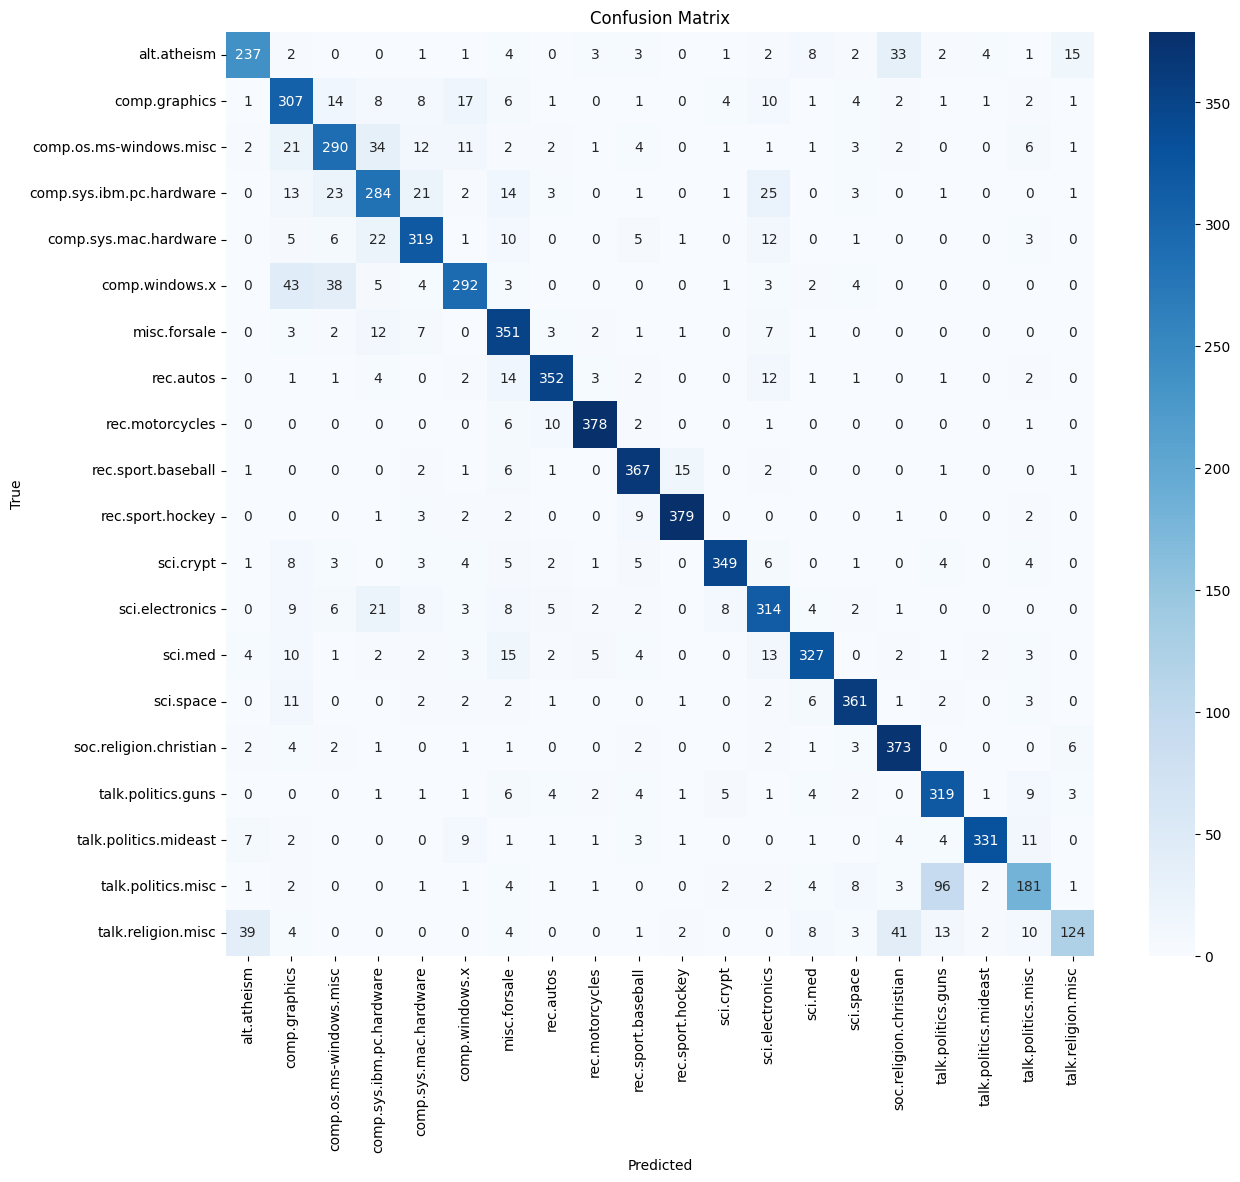

In [13]:
cm = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=newsgroups_test.target_names, yticklabels=newsgroups_test.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Матриця показує, що модель працює добре, оскільки більшість правильних відповідей зосереджена по діагоналі. Проте вона часто плутається у дуже схожих або суміжних темах: наприклад, загальні розмови про політику легко плутає з обговоренням зброї, різні релігійні теми зводить до християнства чи атеїзму, а також не завжди розрізняє комп'ютерні операційні системи між собою.


Метрики точності



In [14]:
print("7. Звіт про класифікацію:")
print(classification_report(y_test, y_pred_tfidf, target_names=newsgroups_test.target_names))


7. Звіт про класифікацію:
                          precision    recall  f1-score   support

             alt.atheism       0.80      0.74      0.77       319
           comp.graphics       0.69      0.79      0.74       389
 comp.os.ms-windows.misc       0.75      0.74      0.74       394
comp.sys.ibm.pc.hardware       0.72      0.72      0.72       392
   comp.sys.mac.hardware       0.81      0.83      0.82       385
          comp.windows.x       0.83      0.74      0.78       395
            misc.forsale       0.76      0.90      0.82       390
               rec.autos       0.91      0.89      0.90       396
         rec.motorcycles       0.95      0.95      0.95       398
      rec.sport.baseball       0.88      0.92      0.90       397
        rec.sport.hockey       0.95      0.95      0.95       399
               sci.crypt       0.94      0.88      0.91       396
         sci.electronics       0.76      0.80      0.78       393
                 sci.med       0.89      0.83    

Графіки втрат та точності

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: 

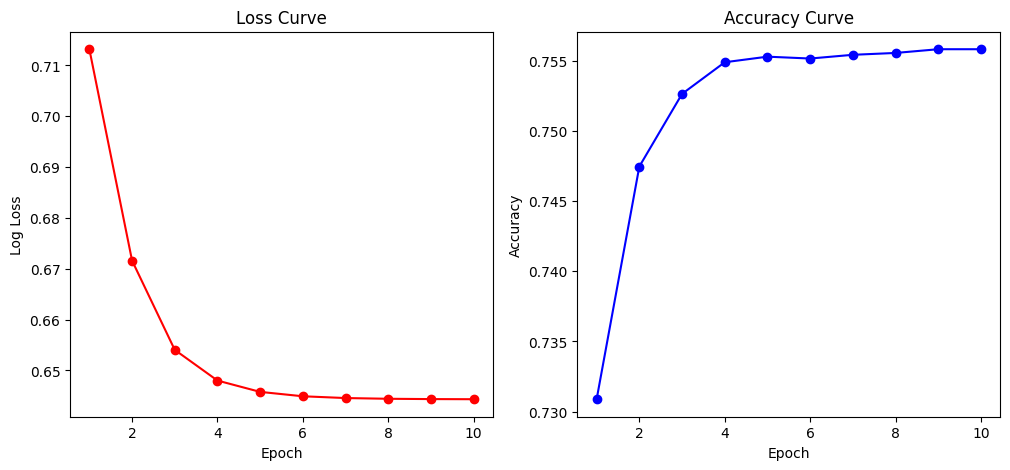

In [15]:
clf_warm = LogisticRegression(warm_start=True, max_iter=1, solver='saga', multi_class='multinomial', random_state=42)
epochs = 10
losses = []
accuracies = []

for epoch in range(epochs):
    clf_warm.fit(X_train_tfidf, y_train)
    y_prob = clf_warm.predict_proba(X_train_tfidf)
    losses.append(log_loss(y_train, y_prob))
    accuracies.append(accuracy_score(y_test, clf_warm.predict(X_test_tfidf)))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), losses, marker='o', color='red')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), accuracies, marker='o', color='blue')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

Loss Curve (Крива втрат): Значення функції втрат (Log Loss) стрімко знижується з ~0.71 до ~0.65 протягом перших 4 епох, після чого стабілізується на рівні ~0.645.

Accuracy Curve (Крива точності): Точність моделі (Accuracy) швидко зростає з ~0.730 до ~0.755 протягом перших 4-5 епох, виходячи на плато після 6-ї епохи.

Модель успішно вчиться. З кожним кроком вона робить менше помилок (втрати падають) і частіше видає правильні відповіді (точність росте). Після 5-6 кроку (епохи) модель досягає своєї межі — подальше тренування вже не покращує її результати.




Вплив стоп-слів

In [16]:
vec_stop = TfidfVectorizer(stop_words='english')
X_tr_stop = vec_stop.fit_transform(X_train_raw)
X_te_stop = vec_stop.transform(X_test_raw)
clf_stop = LogisticRegression(max_iter=1000)
clf_stop.fit(X_tr_stop, y_train)
print(f"9. TfidfVectorizer (stop_words='english'): Accuracy = {accuracy_score(y_test, clf_stop.predict(X_te_stop)):.4f}")

9. TfidfVectorizer (stop_words='english'): Accuracy = 0.8324


Видалення стоп-слів (найбільш вживаних слів, які не несуть смислового навантаження, наприклад, артиклів та прийменників) зменшило кількість "шуму" в даних. Завдяки цьому точність моделі трохи зросла (до 83.2%), оскільки вона змогла краще сфокусуватися на дійсно важливих і унікальних словах, характерних для кожної категорії текстів.

ВИСНОВОК

У результаті виконання практичної роботи було успішно побудовано та проаналізовано моделі класифікації текстових даних. Дослідження підтвердило, що використання TfidfVectorizer є більш ефективним підходом порівняно з CountVectorizer, а вилучення стоп-слів дозволяє зменшити інформаційний шум і підвищити точність класифікації до ~83.2%. Під час порівняння різних алгоритмів найкращу точність продемонструвала модель SVC, проте LogisticRegression виявилася найоптимальнішим вибором завдяки ідеальному балансу між високою точністю та значно більшою швидкістю навчання, тоді як RandomForestClassifier показав найнижчі результати. Аналіз матриці плутанини засвідчив, що модель добре справляється з розпізнаванням текстів, але очікувано стикається з труднощами при розрізненні суміжних категорій зі схожою лексикою (наприклад, різні напрямки політики, релігії чи комп'ютерних технологій). Графіки навчання підтвердили стабільну роботу та швидку збіжність моделі за 5-6 епох, що свідчить про коректне налаштування алгоритмів та успішне вирішення поставленого завдання.


Контрольні питання

*1.	Що таке векторизація тексту і для чого вона потрібна в машинному навчанні?*

Перетворення тексту в числові вектори. Потрібна, оскільки алгоритми машинного навчання працюють лише з числовими даними.

*2.	У чому відмінність між CountVectorizer і TfidfVectorizer?*

CountVectorizer рахує частоту слів, а TfidfVectorizer враховує важливість слова в документі відносно всього корпусу, зменшуючи вагу загальновживаних слів.

*3.	Як параметри min_df, max_df та max_features у векторизаторі впливають на якість класифікації?*

min_df відкидає рідкісні слова, max_df відкидає занадто часті слова, max_features обмежує розмір словника. Це зменшує шум і запобігає перенавчанню.


*4.	Які переваги має TF-IDF у порівнянні з простим методом "мішка слів"?*

Знижує вагу часто вживаних слів і підвищує вагу унікальних термінів, які краще характеризують зміст тексту.

*5.	Що таке логістична регресія і чому її використовують для задач класифікації?*

Це лінійна модель, яка прогнозує ймовірність належності об'єкта до певного класу. Використовується завдяки швидкості та ефективності на розріджених даних.

*6.	Для чого потрібна регуляризація в логістичній регресії (параметр C)?*

Для запобігання перенавчанню шляхом штрафування за занадто великі ваги моделі. Менше значення C означає сильнішу регуляризацію.

*7.	Які категорії даних із "20 Newsgroups" складніше класифікувати та чому?*

Суміжні категорії (наприклад, політика та зброя, або різні види комп'ютерного обладнання), оскільки вони містять багато спільної лексики.

*8.	Що таке матриця плутанини і як її аналізувати?*

Це таблиця для оцінки помилок. Головна діагональ показує правильні прогнози, інші клітинки — кількість хибних класифікацій між конкретними класами.


*9.	Які метрики можна використовувати для оцінки якості класифікації, окрім точності? Поясніть їхню роль.*

Precision (точність розпізнавання конкретного класу), Recall (повнота знаходження об'єктів класу) та F1-score (гармонійне середнє між Precision і Recall).

*10.	Чому важливо оцінювати модель як на тренувальній, так і на тестовій вибірці?*

Щоб виявити перенавчання. Якщо точність на тренувальній висока, а на тестовій низька, модель не здатна до узагальнення.

*11.	Як змінюється точність моделі, якщо використовувати різні методи векторизації (CountVectorizer vs TfidfVectorizer)?*

TfidfVectorizer зазвичай підвищує точність порівняно з CountVectorizer.

*12.	Як	впливають	гіперпараметри	(наприклад,	solver	та	max_iter)	на збіжність моделі?*

solver визначає алгоритм оптимізації, а max_iter задає ліміт ітерацій. Замалий max_iter не дозволить алгоритму знайти оптимальне рішення (не зійдеться).

*13.	Чому важливо тестувати модель на нових текстах, які не входили до тренувальної вибірки?*

Для об'єктивної перевірки здатності моделі працювати з новими, небаченими раніше даними.


*14.	Як змінюється якість класифікації, якщо зменшити розмір тестової вибірки?*

Оцінка якості стає менш репрезентативною та надійною через вищу статистичну похибку.

*15.	Чому параметр stop_words може покращити або погіршити результати класифікації?*

Покращує за рахунок видалення неінформативного шуму; погіршує, якщо серед видалених слів виявляться важливі для контексту класифікації терміни.